#  Data Source

###### Load Dependencies

In [7]:
from importlib import reload
import numpy as np
import scalers
from data import *
from sklearn.preprocessing import OneHotEncoder as HotEncoder
from imputers import *
from scalers import StandardScaler, NormalScaler
import data as db
import encoders as en
reload( en )
import matplotlib.pyplot as plt
reload( db )
import pandas as pd
import warnings
hdr = '\r\n' + '-' * 120 + '\r\n'
nwln = '\r\n'
warnings.filterwarnings( 'ignore' )

###### Load Data

In [8]:
# Load Data
schedx_filepath = r'C:\Users\terry\source\repos\mathy\stores\excel\Combined Schedules.xlsx'
index_columns = [ 'CombinedSchedulesId', ]
nominal_columns = [ 'FY', 'MainAccount', 'Line', 'LineName', ]
out_years = [ f'OY-{i}' for i in range( 1, 10 ) ]
numeric_columns = [ 'PY', 'CY', 'BY' ]
data_columns = [ 'FY', 'MainAccount', 'Line', 'LineName',  ]
all_columns = index_columns + nominal_columns + numeric_columns
max_columns =  data_columns + numeric_columns
dtype_dict = \
{
	'MainAccount': str,
	'TreasurySymbol': str
}

df_excel = pd.read_excel( schedx_filepath, usecols=all_columns, sheet_name='Data'  )
df_excel.reset_index( )
df_excel.round( 2 )
# Fix formatting: pad with leading zeros and split TreasurySymbol
df_excel[ numeric_columns ] = df_excel[ numeric_columns ].round( 2 )
df_excel[ 'MainAccount' ] = df_excel[ 'MainAccount' ].astype( str )
df_excel[ 'MainAccount' ] = df_excel[ 'MainAccount' ].str.zfill( 4 )
df_excel[ 'Line' ] = df_excel[ 'Line' ].astype( str )
df_excel[ 'Line' ] = df_excel[ 'Line' ].str.zfill( 2 )
df_excel[ 'FY' ] = df_excel[ 'FY' ].astype( str )
df_dataset = df_excel[ all_columns ].copy( )
df_nominal = df_excel[ nominal_columns ].copy( )
df_numeric = df_excel[ numeric_columns ].copy( )
df_schedx = df_excel[ max_columns ].copy( )
sns.set_style( 'darkgrid' )

In [9]:
# Load Data Source
ds = db.DataSource( df=df_schedx, target='Line' )
std_data = ds.standardize( )
nml_data = ds.normalize( )
max_data = ds.maxminize( )
ohe= ds.encode_labels( 'Line' )
py = ds.dataframe[ 'PY' ].values
cy = ds.dataframe[ 'CY' ].values

# Classification Models

In [10]:
import classifications as cs
reload( cs )

<module 'classifications' from 'C:\\Users\\terry\\source\\repos\\Mathy\\classifications.py'>

####  🧠 Perceptron

In [11]:
percetron = cs.Perceptron( )
X = ds.numeric_data.values
y = ds.targets
percetron.train( X, y )
percetron.score( X, y )

,Training Score,Testing Score,Precision Score,Accuracy Score,Recall Score,Balanced Accuracy,F Score
0,0.019685,0.031461,0.0,0.022042,0.0,0.005051,0.0
1,0.019685,0.031461,0.0,0.022042,0.0,0.005051,0.0
2,0.019685,0.031461,0.0,0.022042,0.0,0.005051,0.0
3,0.019685,0.031461,0.0,0.022042,0.0,0.005051,0.0
4,0.019685,0.031461,0.0,0.022042,0.0,0.005051,0.0
...,...,...,...,...,...,...,...
346,0.019685,0.031461,0.0,0.022042,0.0,0.005051,0.0
347,0.019685,0.031461,0.0,0.022042,0.0,0.005051,0.0
348,0.019685,0.031461,0.0,0.022042,0.0,0.005051,0.0
349,0.019685,0.031461,0.0,0.022042,0.0,0.005051,0.0


In [12]:
cat = ds.encode_categorical( )
cat



,FY,MainAccount,Line,LineName
FY,NaN,NaN,NaN,NaN
MainAccount,NaN,NaN,NaN,NaN
Line,NaN,NaN,NaN,NaN
LineName,NaN,NaN,NaN,NaN


####  📈 Least Squares

In [90]:
least_squares = cs.LeastSquares( )
X = ds.standardize( )
y = ds.targets
least_squares.train( X, y )
least_squares.score( X, y )

,Training Score,Testing Score,Precision Score,Accuracy Score,Recall Score,Balanced Accuracy,F Score
0,1.0,1.0,0.004498,0.004498,1.0,0.002849,0.008957
1,1.0,1.0,0.000000,0.004498,0.0,0.002849,0.000000
2,1.0,1.0,0.000000,0.004498,0.0,0.002849,0.000000
3,1.0,1.0,0.000000,0.004498,0.0,0.002849,0.000000
4,1.0,1.0,0.000000,0.004498,0.0,0.002849,0.000000
...,...,...,...,...,...,...,...
346,1.0,1.0,0.000000,0.004498,0.0,0.002849,0.000000
347,1.0,1.0,0.000000,0.004498,0.0,0.002849,0.000000
348,1.0,1.0,0.000000,0.004498,0.0,0.002849,0.000000
349,1.0,1.0,0.000000,0.004498,0.0,0.002849,0.000000


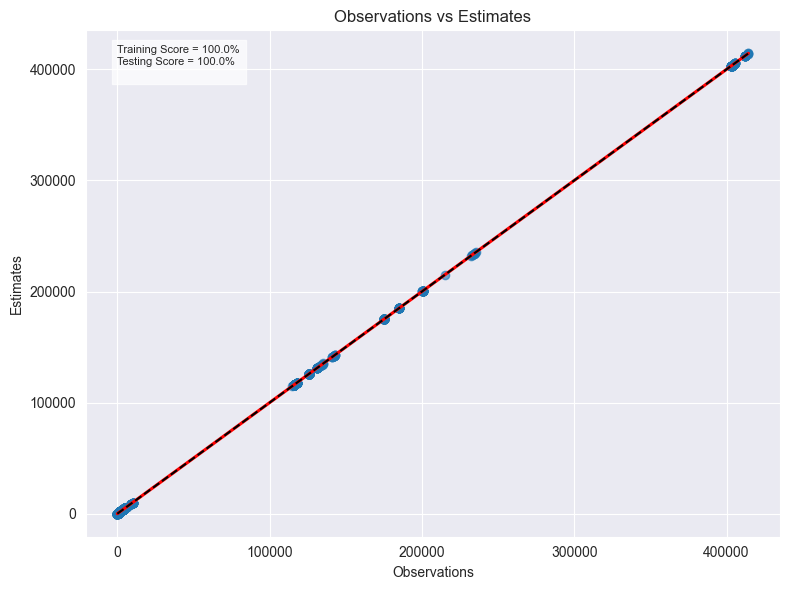

In [30]:
least_squares.scatter_plot( X, y )

####  📉 Logistic Regression

In [28]:
logistic = cs.LogisticRegression( )
X = ds.standardize( )
y = ds.encode_targets()
logistic.train( X, y )
logistic.score( X, y )

,Training Score,Testing Score,Precision Score,Accuracy Score,Recall Score,Balanced Accuracy,F Score
0,0.075928,0.092135,0.000000,0.001799,0.0,0.002849,0.000000
1,0.075928,0.092135,0.001799,0.001799,1.0,0.002849,0.003592
2,0.075928,0.092135,0.000000,0.001799,0.0,0.002849,0.000000
3,0.075928,0.092135,0.000000,0.001799,0.0,0.002849,0.000000
4,0.075928,0.092135,0.000000,0.001799,0.0,0.002849,0.000000
...,...,...,...,...,...,...,...
346,0.075928,0.092135,0.000000,0.001799,0.0,0.002849,0.000000
347,0.075928,0.092135,0.000000,0.001799,0.0,0.002849,0.000000
348,0.075928,0.092135,0.000000,0.001799,0.0,0.002849,0.000000
349,0.075928,0.092135,0.000000,0.001799,0.0,0.002849,0.000000


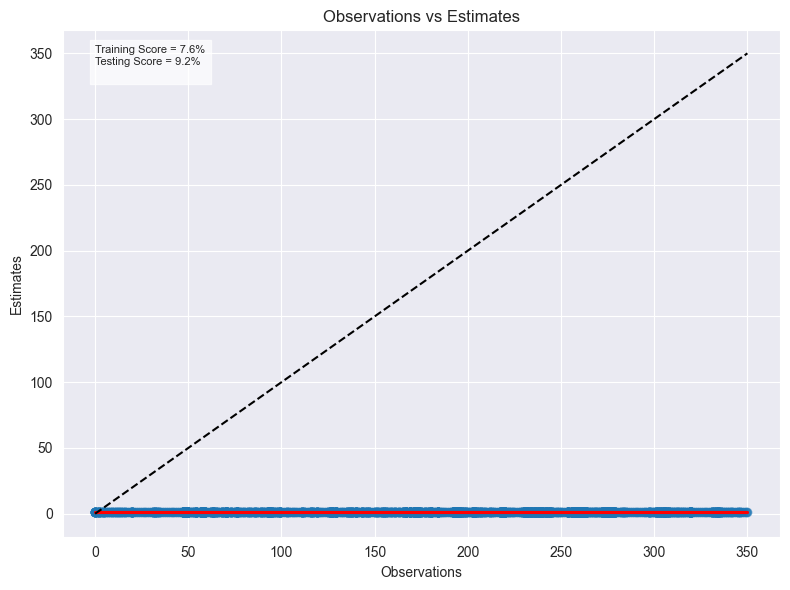

In [22]:
logistic.scatter_plot( X, y )

####  🎯️ LASSO

In [24]:
lasso = cs.Lasso( )
X = ds.standardize( )
y = ds.targets
lasso.train( X, y )
lasso.score( X, y )

,Training Score,Testing Score,Precision Score,Accuracy Score,Recall Score,Balanced Accuracy,F Score
0,1.0,1.0,0.0000,0.004498,0.0,0.002849,0.000000
1,1.0,1.0,0.0045,0.004498,1.0,0.002849,0.008961
2,1.0,1.0,0.0000,0.004498,0.0,0.002849,0.000000
3,1.0,1.0,0.0000,0.004498,0.0,0.002849,0.000000
4,1.0,1.0,0.0000,0.004498,0.0,0.002849,0.000000
...,...,...,...,...,...,...,...
347,1.0,1.0,0.0000,0.004498,0.0,0.002849,0.000000
348,1.0,1.0,0.0000,0.004498,0.0,0.002849,0.000000
349,1.0,1.0,0.0000,0.004498,0.0,0.002849,0.000000
350,1.0,1.0,0.0000,0.004498,0.0,0.002849,0.000000


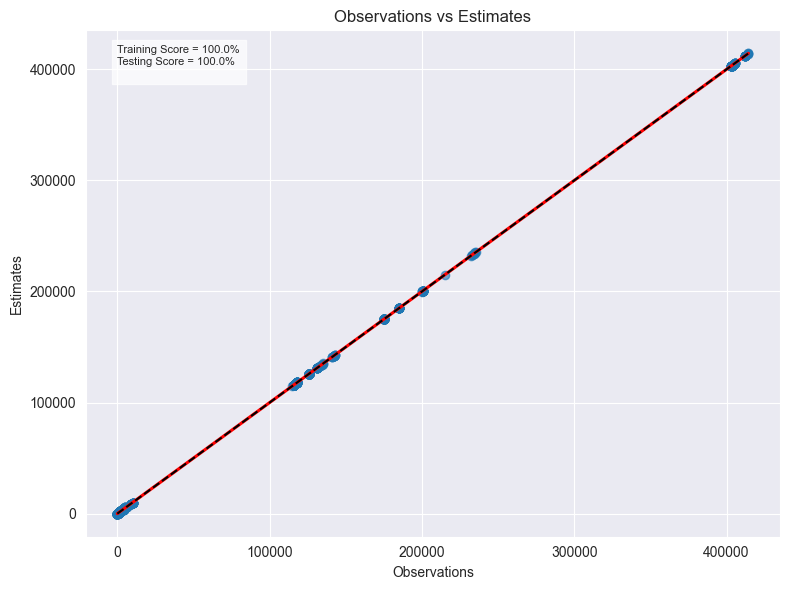

In [25]:
lasso.scatter_plot( X, y )

####  📊  Ridge

In [41]:
ridge = cs.Ridge( )
X = ds.standardize( )
y = ds.targets
ridge.train( X, y )
ridge.score( X, y )

,Training Score,Testing Score,Precision Score,Accuracy Score,Recall Score,Balanced Accuracy,F Score
0,0.050056,0.049438,0.0,0.049933,0.0,0.00711,0.0
1,0.050056,0.049438,0.0,0.049933,0.0,0.00711,0.0
2,0.050056,0.049438,0.0,0.049933,0.0,0.00711,0.0
3,0.050056,0.049438,0.0,0.049933,0.0,0.00711,0.0
4,0.050056,0.049438,0.0,0.049933,0.0,0.00711,0.0
...,...,...,...,...,...,...,...
346,0.050056,0.049438,0.0,0.049933,0.0,0.00711,0.0
347,0.050056,0.049438,0.0,0.049933,0.0,0.00711,0.0
348,0.050056,0.049438,0.0,0.049933,0.0,0.00711,0.0
349,0.050056,0.049438,0.0,0.049933,0.0,0.00711,0.0


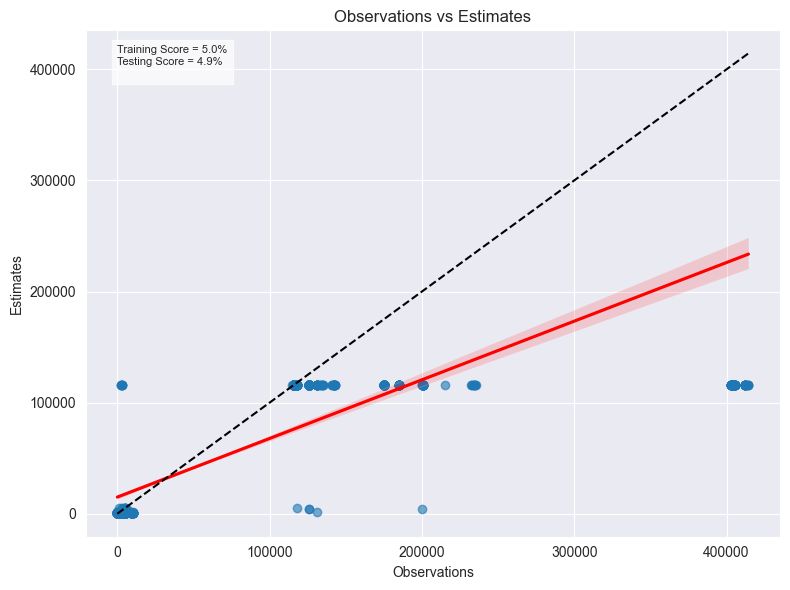

In [42]:
ridge.scatter_plot( X, y )

####  📉 Gradient Descent

In [57]:
gradient = cs.GradientDescent( )
X = ds.normalize( )
y = ds.encode_targets( )
gradient.train( X, y )
gradient.score( X, y )

,Training Score,Testing Score,Precision Score,Accuracy Score,Recall Score,Balanced Accuracy,F Score
0,0.08324,0.076404,0.0,0.081871,0.0,0.010678,0.0
1,0.08324,0.076404,0.0,0.081871,0.0,0.010678,0.0
2,0.08324,0.076404,0.0,0.081871,0.0,0.010678,0.0
3,0.08324,0.076404,0.0,0.081871,0.0,0.010678,0.0
4,0.08324,0.076404,0.0,0.081871,0.0,0.010678,0.0
...,...,...,...,...,...,...,...
346,0.08324,0.076404,0.0,0.081871,0.0,0.010678,0.0
347,0.08324,0.076404,0.0,0.081871,0.0,0.010678,0.0
348,0.08324,0.076404,0.0,0.081871,0.0,0.010678,0.0
349,0.08324,0.076404,0.0,0.081871,0.0,0.010678,0.0


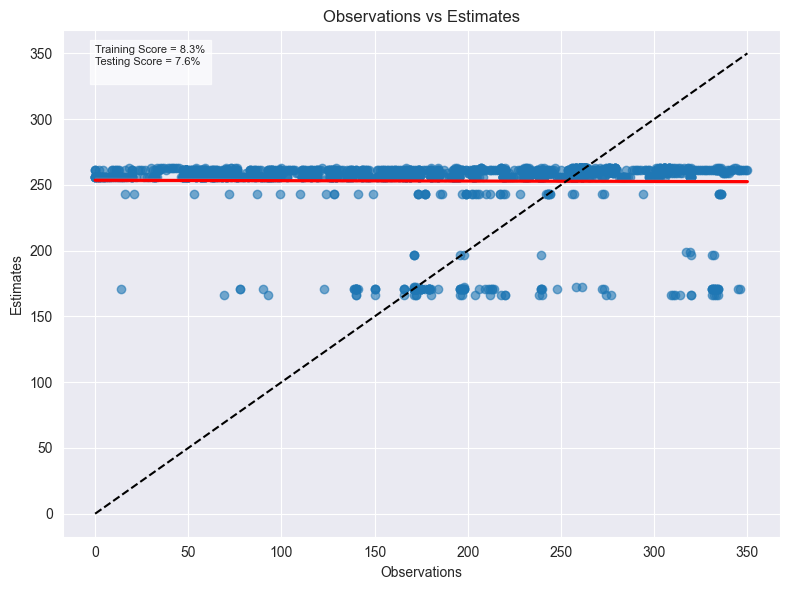

In [58]:
gradient.scatter_plot( X, y )

####  🎭 Nearest Neighbor

In [63]:
neighbors = cs.NearestNeighbor( )
X = ds.maxminize()
y = ds.targets
neighbors.train( X, y )
neighbors.score( X, y )

,Training Score,Testing Score,Precision Score,Accuracy Score,Recall Score,Balanced Accuracy,F Score
0,0.614173,0.606742,0.357143,0.612686,1.000000,0.354157,0.526316
1,0.614173,0.606742,0.166667,0.612686,0.250000,0.354157,0.200000
2,0.614173,0.606742,0.444444,0.612686,0.571429,0.354157,0.500000
3,0.614173,0.606742,0.000000,0.612686,0.000000,0.354157,0.000000
4,0.614173,0.606742,0.000000,0.612686,0.000000,0.354157,0.000000
...,...,...,...,...,...,...,...
346,0.614173,0.606742,0.200000,0.612686,0.333333,0.354157,0.250000
347,0.614173,0.606742,0.000000,0.612686,0.000000,0.354157,0.000000
348,0.614173,0.606742,0.000000,0.612686,0.000000,0.354157,0.000000
349,0.614173,0.606742,0.000000,0.612686,0.000000,0.354157,0.000000


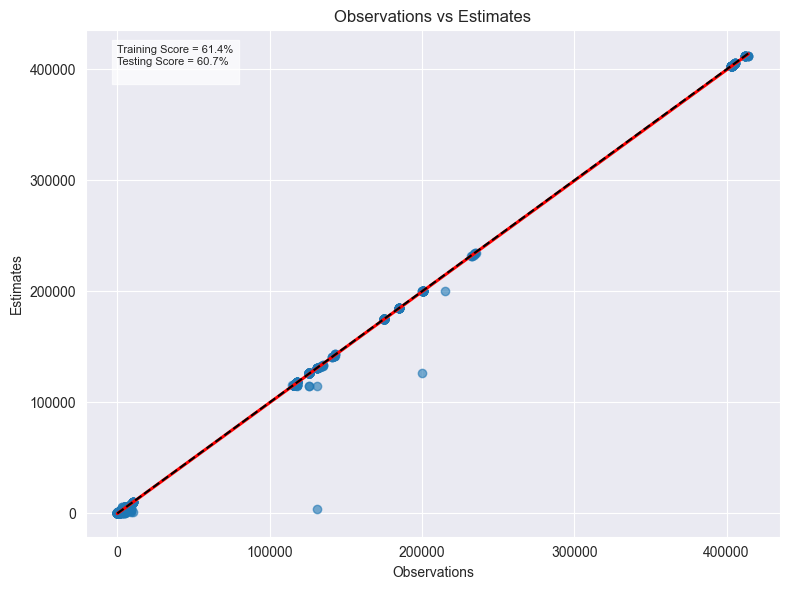

In [64]:
neighbors.scatter_plot( X, y )

#### 🔧 Adaptive Boost

In [71]:
adaptive = cs.AdaptiveBoost( )
X = ds.data
y = ds.targets
adaptive.train( X, y )
adaptive.score( X, y )

,Training Score,Testing Score,Precision Score,Accuracy Score,Recall Score,Balanced Accuracy,F Score
0,0.151294,0.130337,1.0,0.147099,1.0,0.099715,1.0
1,0.151294,0.130337,1.0,0.147099,1.0,0.099715,1.0
2,0.151294,0.130337,1.0,0.147099,1.0,0.099715,1.0
3,0.151294,0.130337,1.0,0.147099,1.0,0.099715,1.0
4,0.151294,0.130337,0.0,0.147099,0.0,0.099715,0.0
...,...,...,...,...,...,...,...
346,0.151294,0.130337,0.0,0.147099,0.0,0.099715,0.0
347,0.151294,0.130337,0.0,0.147099,0.0,0.099715,0.0
348,0.151294,0.130337,0.0,0.147099,0.0,0.099715,0.0
349,0.151294,0.130337,0.0,0.147099,0.0,0.099715,0.0


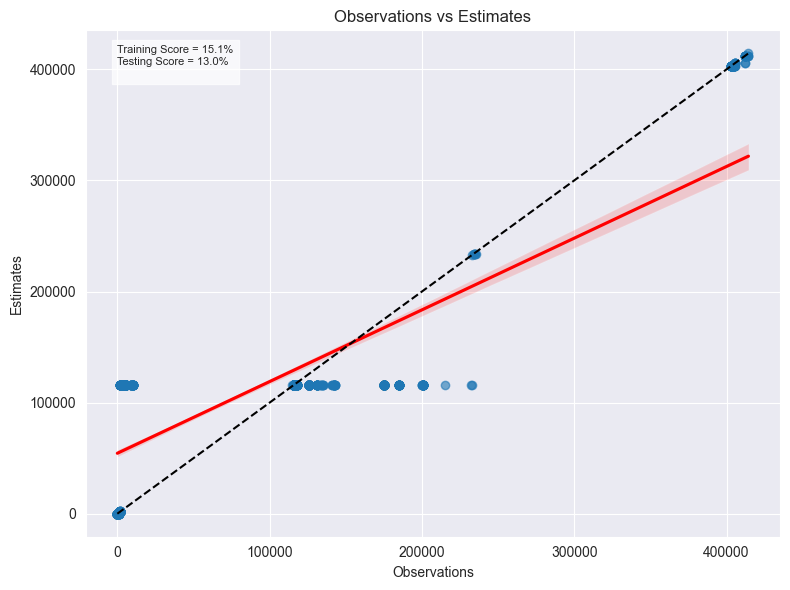

In [72]:
adaptive.scatter_plot( X, y )

#### 🗃️ Bagging Model

In [75]:
bagging = cs.BaggingModel( )
X = ds.data
y = ds.targets
bagging.train( X, y )
bagging.score( X, y )

,Training Score,Testing Score,Precision Score,Accuracy Score,Recall Score,Balanced Accuracy,F Score
0,0.955006,0.961798,1.000,0.956365,1.0,0.871427,1.000000
1,0.955006,0.961798,1.000,0.956365,1.0,0.871427,1.000000
2,0.955006,0.961798,0.875,0.956365,1.0,0.871427,0.933333
3,0.955006,0.961798,1.000,0.956365,1.0,0.871427,1.000000
4,0.955006,0.961798,1.000,0.956365,1.0,0.871427,1.000000
...,...,...,...,...,...,...,...
346,0.955006,0.961798,1.000,0.956365,1.0,0.871427,1.000000
347,0.955006,0.961798,0.000,0.956365,0.0,0.871427,0.000000
348,0.955006,0.961798,0.250,0.956365,1.0,0.871427,0.400000
349,0.955006,0.961798,0.000,0.956365,0.0,0.871427,0.000000


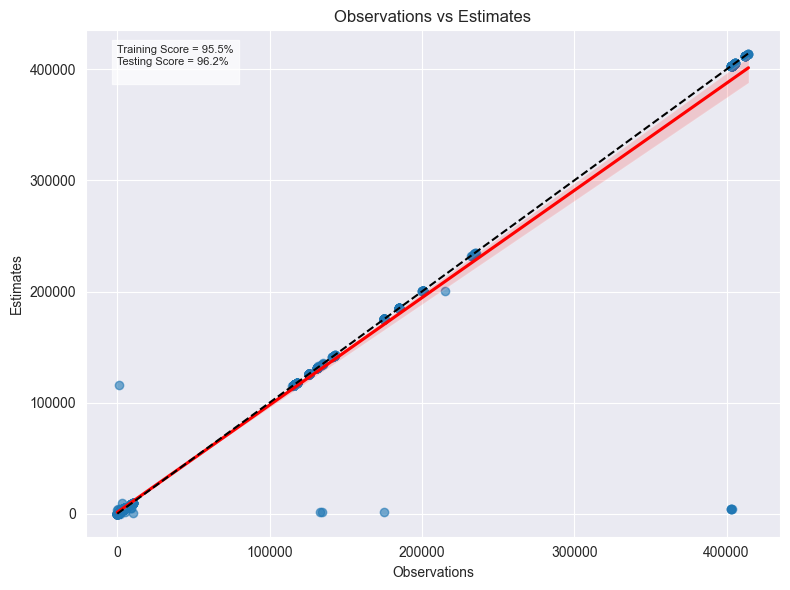

In [76]:
bagging.scatter_plot( X, y )

#### ✨ Support Vector Machine

In [81]:
support = cs.SupportVector( )
X = ds.data
y = ds.targets
support.train( X, y )
support.score( X, y )

,Training Score,Testing Score,Precision Score,Accuracy Score,Recall Score,Balanced Accuracy,F Score
0,0.053993,0.049438,0.0,0.053081,0.0,0.007641,0.0
1,0.053993,0.049438,0.0,0.053081,0.0,0.007641,0.0
2,0.053993,0.049438,0.0,0.053081,0.0,0.007641,0.0
3,0.053993,0.049438,0.0,0.053081,0.0,0.007641,0.0
4,0.053993,0.049438,0.0,0.053081,0.0,0.007641,0.0
...,...,...,...,...,...,...,...
346,0.053993,0.049438,0.0,0.053081,0.0,0.007641,0.0
347,0.053993,0.049438,0.0,0.053081,0.0,0.007641,0.0
348,0.053993,0.049438,0.0,0.053081,0.0,0.007641,0.0
349,0.053993,0.049438,0.0,0.053081,0.0,0.007641,0.0


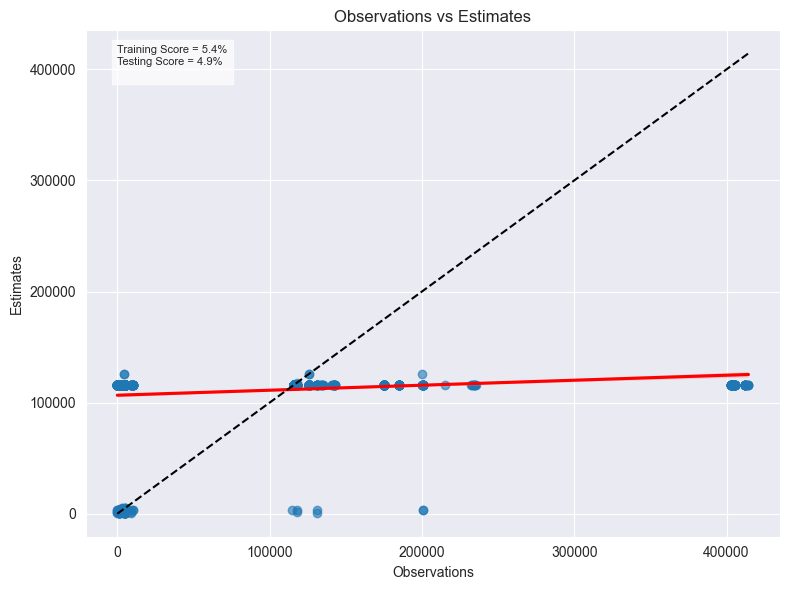

In [82]:
support.scatter_plot( X, y )

# Regression Models


In [7]:
import regressions as rs
reload( rs )

<module 'regressions' from 'C:\\Users\\terry\\source\\repos\\Mathy\\regressions.py'>

#### 📦 Least Squares

In [8]:
ls_regressor = rs.LeastSquares( )
X = data.values
y = ds.targets
ls_regressor.train( X, y )
ls_regressor.score( X, y )

,Training Score,Testing Score,R Squared Score,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Max Error,Explained Variance Score
0,1.0,1.0,1.0,2.565653e-07,5.677584e-13,0.0,0.000015,1.0
1,1.0,1.0,1.0,2.565653e-07,5.677584e-13,0.0,0.000015,1.0
2,1.0,1.0,1.0,2.565653e-07,5.677584e-13,0.0,0.000015,1.0
3,1.0,1.0,1.0,2.565653e-07,5.677584e-13,0.0,0.000015,1.0
4,1.0,1.0,1.0,2.565653e-07,5.677584e-13,0.0,0.000015,1.0
5,1.0,1.0,1.0,2.565653e-07,5.677584e-13,0.0,0.000015,1.0
6,1.0,1.0,1.0,2.565653e-07,5.677584e-13,0.0,0.000015,1.0
7,1.0,1.0,1.0,2.565653e-07,5.677584e-13,0.0,0.000015,1.0


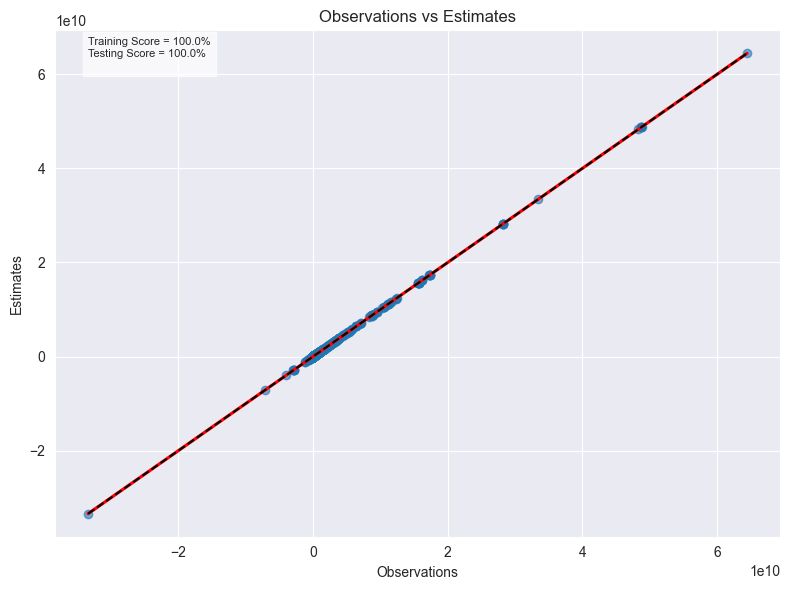

In [9]:
ls_regressor.scatter_plot( X, y )

#### 🔧 Ridge

In [ ]:
ridge_regressor = rs.Ridge( )
X = data.values
y = ds.targets
ridge_regressor.train( X, y )
ridge_regressor.score( X, y )

In [ ]:
ridge_regressor.scatter_plot( X, y )

#### ⚙️ LASSO

In [ ]:
lasso_regressor = rs.Lasso( )
X = data.values
y = ds.targets
lasso_regressor.train( X, y )
lasso_regressor.score( X, y )

In [ ]:
lasso_regressor.scatter_plot( X, y )

#### 🧪 Elastic Net

In [ ]:
elastic_regressor = rs.ElasticNet( )
X = data.values
y = ds.targets
elastic_regressor.train( X, y )
elastic_regressor.score( X, y )

In [ ]:
elastic_regressor.scatter_plot( X, y )

#### 📉 Gradient Descent

In [ ]:
sgd_regressor = rs.GradientDescent( )
X = data.values
y = ds.targets
sgd_regressor.train( X, y )
sgd_regressor.score( X, y )

In [ ]:
sgd_regressor.scatter_plot( X, y )

#### 🎭 Nearest Neighbor

In [ ]:
knn_regressor = rs.NearestNeighbor( )
X = data.values
y = ds.targets
knn_regressor.train( X, y )
knn_regressor.score( X, y )

In [ ]:
knn_regressor.scatter_plot( X, y )

#### 🚀 Gradient Boost

In [ ]:
gb_regressor = rs.GradientBoost( )
X = data.values
y = ds.targets
gb_regressor.train( X, y )
gb_regressor.score( X, y )

In [ ]:
gb_regressor.scatter_plot( X, y )

#### 🎨 Adaptive Boost

In [ ]:
adaptive_regressor = rs.AdaptiveBoost( )
X = data.values
y = ds.targets
adaptive_regressor.train( X, y )
adaptive_regressor.score( X, y )

In [ ]:
adaptive_regressor.scatter_plot( X, y )

#### 📁 Least Angle

In [ ]:
angle_regressor = rs.LeastAngle( )
X = data.values
y = ds.targets
angle_regressor.train( X, y )
angle_regressor.score( X, y )

In [ ]:
angle_regressor.scatter_plot( X, y )

#### 🔬 Bayesian

In [ ]:
bayesian_regressor = rs.Bayesian( )
X = data.values
y = ds.targets
bayesian_regressor.train( X, y )
bayesian_regressor.score( X, y )

In [ ]:
bayesian_regressor.scatter_plot( X, y )

#### ✨ Gaussian Process

In [ ]:
gaussian_regressor = rs.GaussianProcess( )
X = data.values
y = ds.targets
gaussian_regressor.train( X, y )
gaussian_regressor.score( X, y )

In [ ]:
gaussian_regressor.scatter_plot( X, y )

#### 🚀 Support Vector Machine

In [ ]:
svm_regressor = rs.SupportVector( )
X = data.values
y = ds.targets
svm_regressor.train( X, y )
svm_regressor.score( X, y )

In [ ]:
svm_regressor.scatter_plot( X, y )